# Обработка пропусков и дубликатов
**Цель работы:**
Научиться выявлять, анализировать и обрабатывать пропущенные значения и дубликаты в больших датасетах, используя библиотеки Pandas.

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Объяснение столбцов:
```
'employee_id' : Номер сотрудника
'full_name': полное имя
'gender': пол
'birth_date': дата рождения
'hire_date': дата найма
'department': отдел
'position': должность
'salary': зарплата
'bonus': бонус
'experience_years': опыт
'projects completed': завершенные проекты
'city': город
'email': электронная почта
'phone': телефон
'performance score': оценка эффективности
'last_promotion_date': дата последняго дня продвижения
'vacation_days_used': дни отпуска использованы
'education_level': уровень образования
'certifications': количество сертификатов (повышение квалификации, курсы и т.д.)
'team_size': количество членов команды
```

# № 1. Первичный анализ данных

Необходимо исследовать структуру данных прежде чем выполнять обработку пропусков.

Необходимо вывести:
*   Первые 5 строк
*   Информация о столбцах
*   Статистика числовых столбцов
*   Статистика по категориальным столбцам

In [77]:
data = pd.read_csv("employee_data.csv")

df = pd.DataFrame(data)

df.head()

,employee_id,full_name,gender,birth_date,hire_date,department,position,salary,bonus,experience_years,projects_completed,city,email,phone,performance_score,last_promotion_date,vacation_days_used,education_level,certifications,team_size
0,EMP06686,Volkova Anastasiya,Female,1998-11-21,2020-05-15 14:02:20.049925,Финансы,Lead,283000.0,26476.75,6.1,24.0,Москва,volkova.anastasiya@yandex.ru,NaN,4.3,NaN,14.0,Магистр,1.0,22.0
1,EMP09341,Tarasev Petr,Male,1978-01-05,2020-07-31 14:02:20.285656,Продажи,Senior,NaN,12634.84,6.0,16.0,Санкт-Петербург,petr23@yandex.ru,8 (955) 634-31-96,3.3,NaN,1.0,Кандидат наук,4.0,0.0
2,EMP05026,Orlov Andrey,Male,1991-03-04,2024-03-21 14:02:19.803175,R&D,Senior,118000.0,8935.17,2.3,12.0,Саратов,orlov.andrey@yandex.ru,некорректный номер,3.3,2025-03-21 14:02:19.803175,27.0,Магистр,2.0,0.0
3,EMP09705,Belyaeva Aleksandra,Female,1981-03-14,2013-09-16 14:02:20.306527,Консалтинг,Director,622000.0,99935.86,12.8,18.0,Санкт-Петербург,belyaevaa@yandex.ru,89682533660,4.7,2021-09-16 14:02:20.306527,20.0,Магистр,3.0,25.0
4,EMP06206,Sidorova Elena,Female,1980-05-03,2020-11-03 14:02:19.981862,Логистика,Lead,221000.0,18377.69,5.7,6.0,Москва,NaN,NaN,3.9,NaN,10.0,Бакалавр,4.0,9.0


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employee_id          11500 non-null  object 
 1   full_name            11500 non-null  object 
 2   gender               11146 non-null  object 
 3   birth_date           11385 non-null  object 
 4   hire_date            11408 non-null  object 
 5   department           11230 non-null  object 
 6   position             11219 non-null  object 
 7   salary               11048 non-null  float64
 8   bonus                10861 non-null  float64
 9   experience_years     11500 non-null  float64
 10  projects_completed   10733 non-null  float64
 11  city                 11146 non-null  object 
 12  email                10727 non-null  object 
 13  phone                9573 non-null   object 
 14  performance_score    10383 non-null  float64
 15  last_promotion_date  4639 non-null  

In [79]:
df.describe()

,salary,bonus,experience_years,projects_completed,performance_score,vacation_days_used,certifications,team_size
count,1.104800e+04,10861.000000,11500.000000,10733.000000,10383.000000,10874.000000,10294.000000,9034.000000
mean,2.282021e+05,24490.653431,6.695652,21.882512,3.822152,14.716296,2.353993,12.278836
std,2.083716e+05,26161.388560,4.198325,14.196575,0.564295,10.213313,1.557538,16.277813
min,-9.860000e+05,589.730000,0.500000,0.000000,2.500000,0.000000,0.000000,0.000000
25%,8.900000e+04,5887.390000,3.000000,11.000000,3.400000,7.000000,1.000000,0.000000
50%,1.810000e+05,15553.700000,6.100000,20.000000,3.800000,14.000000,2.000000,0.000000
75%,3.150000e+05,33914.210000,10.100000,32.000000,4.200000,22.000000,4.000000,25.000000
max,5.210000e+06,213500.190000,15.000000,73.000000,5.000000,100.000000,5.000000,50.000000


In [80]:
df.describe(include='object')

,employee_id,full_name,gender,birth_date,hire_date,department,position,city,email,phone,last_promotion_date,education_level
count,11500,11500,11146,11385,11408,11230,11219,11146,10727,9573,4639,10791
unique,10000,1350,2,7041,9937,10,7,20,6680,8280,4219,5
top,EMP04162,Fedorov Sergey,Female,2000-12-06,2024-11-18 14:02:19.700919,Продажи,Senior,Москва,alekseevaa@yandex.ru,некорректный номер,2025-05-05 14:02:20.127474,Магистр
freq,2,20,5601,7,2,2754,2459,3243,13,159,2,3997


Вопросы:

In [81]:
# Сколько всего строк и столбцов в датасете?
df.shape

(11500, 20)

In [82]:
# Какие типы данных присутствуют?
df.dtypes.unique()

array([dtype('O'), dtype('float64')], dtype=object)

In [83]:
# Сколько числовых и сколько категориальных столбцов?
print("Числовых столбцов:", df.select_dtypes(include='number').shape[1])
print("Категориальных столбцов:", df.select_dtypes(include='object').shape[1])

Числовых столбцов: 8
Категориальных столбцов: 12


Анализ пропусков
* Создайте DataFrame с информацией о пропусках со следующей структурой:
```
'Тип данных'
'Всего значений'
'Пропущено'
'Процент пропусков'
```
* Визуализируйте пропуски:

Воспользуйтесь функцией bar

Название - Процент пропусков по столбцам

х - Процент пропусков по столбцам

у - Процент пропусков (%)


* Постройте матрицу пропусков (heatmap):

Название - Матрица пропусков (желтый = пропуск)

х - Столбцы

у - Строки (первые 1000)



In [84]:
missing = pd.DataFrame({
    'Тип данных': df.dtypes,
    'Всего значений': len(df),
    'Пропущено': df.isna().sum(),
    'Процент пропусков': df.isna().mean() * 100
})

missing

,Тип данных,Всего значений,Пропущено,Процент пропусков
employee_id,object,11500,0,0.000000
full_name,object,11500,0,0.000000
gender,object,11500,354,3.078261
birth_date,object,11500,115,1.000000
hire_date,object,11500,92,0.800000
department,object,11500,270,2.347826
position,object,11500,281,2.443478
salary,float64,11500,452,3.930435
bonus,float64,11500,639,5.556522
experience_years,float64,11500,0,0.000000


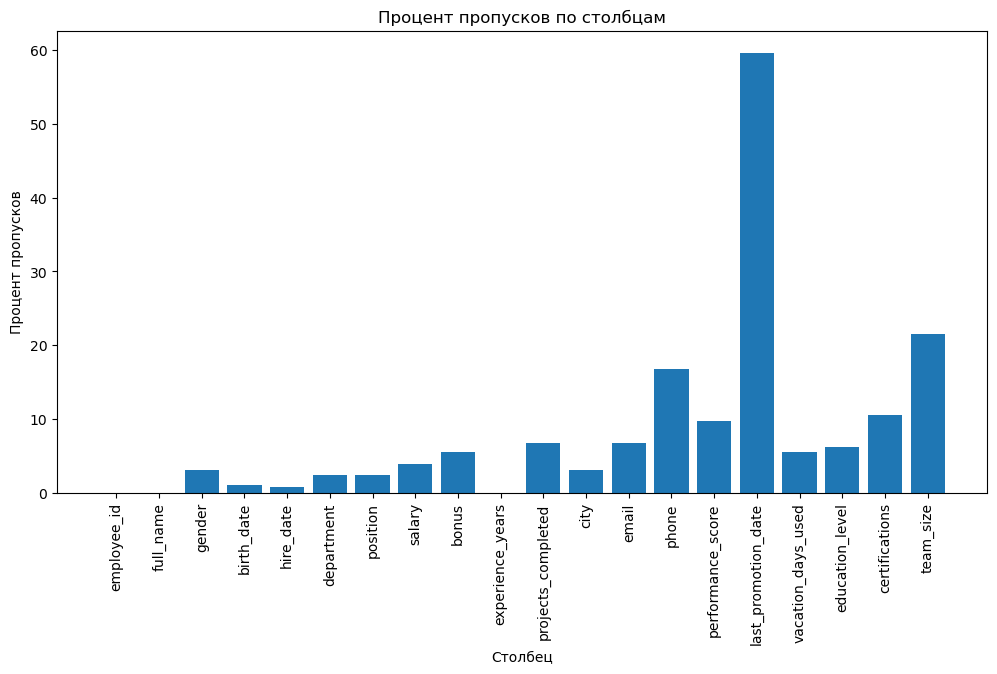

In [85]:
plt.figure(figsize=(12, 6))

plt.bar(missing.index, missing['Процент пропусков'])

plt.title('Процент пропусков по столбцам')
plt.xlabel('Столбец')
plt.ylabel('Процент пропусков')

plt.xticks(rotation=90)
plt.show()

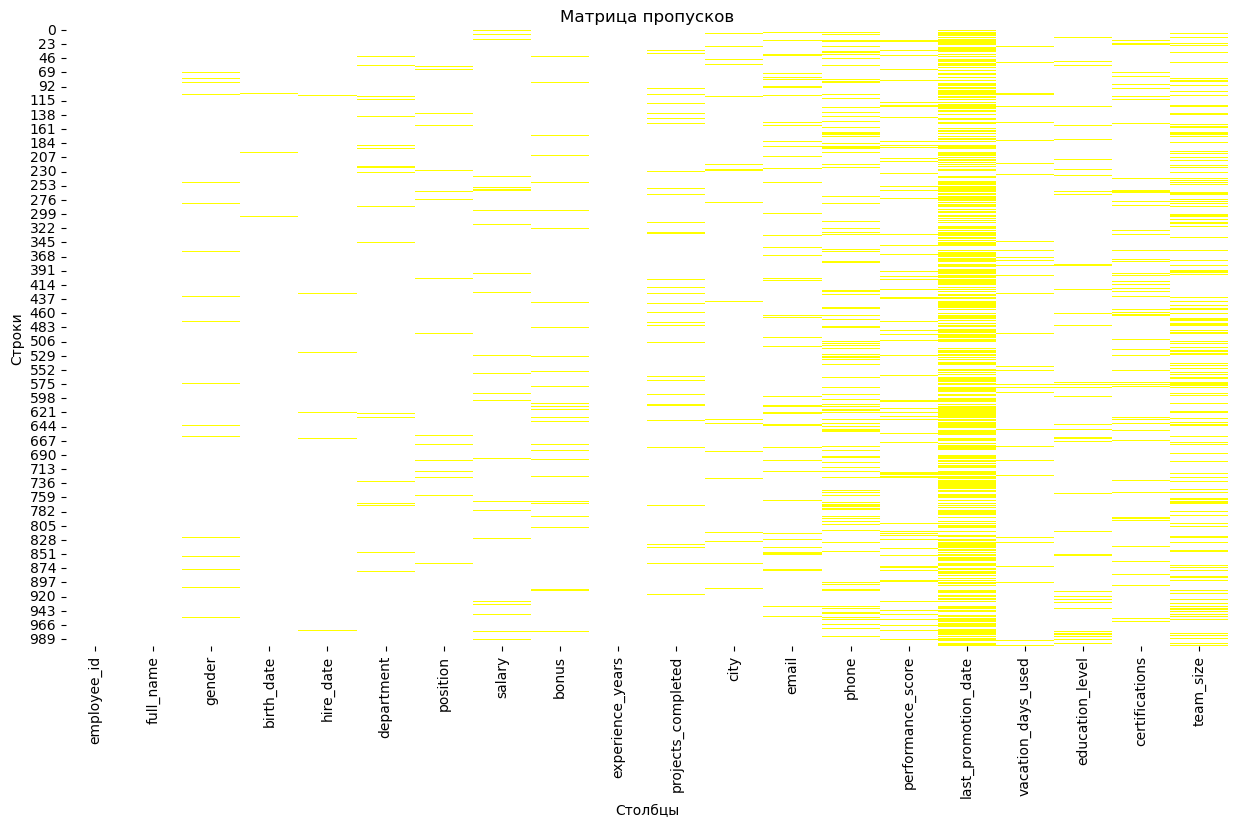

In [86]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    df.head(1000).isna(),
    cmap=['white', 'yellow'],
    cbar=False
)

plt.title('Матрица пропусков')
plt.xlabel('Столбцы')
plt.ylabel('Строки')

plt.show()

Вопросы:

In [87]:
# В каких 3 столбцах наибольший процент пропусков?
missing.sort_values('Процент пропусков', ascending=False).head(3)

,Тип данных,Всего значений,Пропущено,Процент пропусков
last_promotion_date,object,11500,6861,59.660870
team_size,float64,11500,2466,21.443478
phone,object,11500,1927,16.756522


In [88]:
# Сколько строк не содержат ни одного пропуска?
df.dropna().shape[0]

1508

In [89]:
# Какой процент данных потеряется при удалении всех строк с пропусками?
lost_percent = (1 - df.dropna().shape[0] / len(df)) * 100

lost_percent

86.88695652173914

# № 2. Обработка пропусков

* Удалите строки с любыми пропусками, отобразите:

Исходный размер:

Новый размер:

Потеря данных:




*   Удаление столбцов с большим процентом пропусков

threshold = 0.3  # 30%

Удалено столбцов:

Удаленные столбцы:

Новый размер:


*   Условное удаление строк

Удаляем строки, где пропущено более 50% столбцов

threshold_cols = int(len(df.columns) * 0.5)

* Удаление на основе важности столбцов

Определяем критически важные столбцы

critical_cols = ['employee_id', 'full_name', 'department', 'position', 'salary']


In [90]:
# Удаление с любыми пропусками
original_shape = df.shape

df_no_na = df.dropna()

new_shape = df_no_na.shape

lost_rows = original_shape[0] - new_shape[0]
lost_percent = lost_rows / original_shape[0] * 100

print("Исходный размер:", original_shape)
print("Новый размер:", new_shape)
print("Потеря данных:", round(lost_percent, 2), "%")

Исходный размер: (11500, 20)
Новый размер: (1508, 20)
Потеря данных: 86.89 %


In [91]:
threshold = 30

# Столбцы, где больше 30% пропусков
columns_to_drop = missing[missing['Процент пропусков'] > threshold].index

df_clean = df.drop(columns=columns_to_drop)

print("Удалено столбцов:", len(columns_to_drop))
print("Удаленные столбцы:", *list(columns_to_drop))
print("Новый размер:", df_clean.shape)

Удалено столбцов: 1
Удаленные столбцы: last_promotion_date
Новый размер: (11500, 19)


In [102]:
# Условное удаление строк
threshold_cols = int(len(df.columns) * 0.5)

missing_per_row = df.isna().sum(axis=1)

df_conditional = df[missing_per_row <= threshold_cols]

print("Исходный размер:", df.shape)
print("Новый размер:", df_conditional.shape)
print("Удалено строк:", df.shape[0] - df_conditional.shape[0])

Исходный размер: (11500, 20)
Новый размер: (11500, 20)
Удалено строк: 0


In [98]:
critical_cols = [
    'employee_id',
    'full_name',
    'department',
    'position',
    'salary'
]

df_critical = df.dropna(subset=critical_cols)

print("Исходный размер:", df.shape)
print("Новый размер:", df_critical.shape)
print("Удалено строк:", df.shape[0] - df_critical.shape[0])

Исходный размер: (11500, 20)
Новый размер: (10517, 20)
Удалено строк: 983


Вопросы:
1. Какой метод удаления приводит к наименьшей потере данных?
- условное удаление
2. Почему удаление столбцов может быть опасным?
- сокращает число полезных признаков, ухудшает качество анализа, может привести к потере закономерностей в данных
3. В каких случаях стоит использовать стратегическое удаление?
- в критически важном столбце пропуски делают строку непригодной для анализа
- наличие пропуска означает отсутствие необходимой характеристики
- пропуски невозможно восстановить

Заполнение пропусков

Заполнение константами для разных типов данных

1. Заполнение константами:

*Для категориальных данных* - **"Не указано"**

*Для числовых данных* - **-1**

*Для дат* - **'1900-01-01'**

2. Заполнение статистическими показателями:

*Для каждого числового столбца:*

Сильно асимметричное распределение - медиана

Более симметричное распределение - среднее

*Для категориальных - модой*

3. Групповое заполнение

Зарплата по позиции и городу

Бонус как процент от зарплаты


In [103]:
# Заполнение константами

df_filled = df.copy()

categorical_cols = df_filled.select_dtypes(include='object').columns
numeric_cols = df_filled.select_dtypes(include='number').columns
date_cols = ['birth_date', 'hire_date', 'last_promotion_date']

# Категориальные - "Не указано"
df_filled[categorical_cols] = df_filled[categorical_cols].fillna('Не указано')

# Числовые - -1
df_filled[numeric_cols] = df_filled[numeric_cols].fillna(-1)

# Даты - 1900-01-01
for col in date_cols:
    df_filled[col] = df_filled[col].fillna('1900-01-01')

In [ ]:
# Заполнение статистическими показателями

numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include='object').columns

skewness = df[numeric_cols].skew()

df_stat = df.copy()

for col in numeric_cols:
    if abs(skewness[col]) > 1:
        # |skew| > 1 - медиана
        df_stat[col] = df_stat[col].fillna(df_stat[col].median())
    else:
        # |skew| <= 1 - среднее
        df_stat[col] = df_stat[col].fillna(df_stat[col].mean())

for col in categorical_cols:
    # категориальные - мода
    df_stat[col] = df_stat[col].fillna(df_stat[col].mode()[0])

In [107]:
# Групповое заполнение

df_group = df.copy()

salary_group_median = df_group.groupby(['position', 'city'])['salary'].transform('median')

df_group['salary'] = df_group['salary'].fillna(salary_group_median)

bonus_rate = (df_group['bonus'] / df_group['salary']).median()

df_group['bonus'] = df_group['bonus'].fillna(
    df_group['salary'] * bonus_rate
)

Вопросы:
1. Как выбрать между медианой и средним для заполнения?
2. Почему групповое заполнение часто лучше общего?
3. Какие риски у заполнения константами?

# № 3 Обработка дубликатов

Дубликаты могут быть 4-х типов:
*   Полные дубликаты
*   По employee_id
*   По ФИО и email
*   По основным атрибутам ('full_name', 'birth_date', 'city')

Стратегии обработки дубликатов
1. УДАЛЕНИЕ:
* Оставить первую запись
* Оставить последнюю запись
* Удалить все дубликаты

2. Удаление на основе дополнительных условий (например по дате найма)

In [94]:
# Напишите ваш код здесь

Вопросы:
1. Какая стратегия удаления сохраняет наибольшее количество данных?
2. Как выбрать между "первой" и "последней" записью?

# № 4 Практическое применение

Используя очищенные от ошибок и дубликатов данные, сделайте HR статистику:

1. Распределение сотрудников по департаментам
2. Распределение по позициям
3. Средние показатели по департаментам (зарплата, опыт, оценка эффективности, завершенные проекты)
4. Зарплаты по позициям
5. Связь зарплаты и эффективности
6. Эффективность по департаментам

Ключевые выводы для HR-отчета:
* Наиболее оплачиваемый департамент
* Самый эффективный департамент
* Департамент с наибольшим количеством проектов
* Самый опытный департамент
* Проблемные зоны  (Департамент, требующий внимания, низкая оценка)

*Визуализация для отчета (графики):
*   Распределение зарплат по департаментам (boxplot)
*   Зависимость зарплаты от опыта (scatter)
*   Распределение по городам (barh)



In [95]:
# Напишите ваш код здесь

Вопросы:
1. Какие инсайты можно получить из очищенных данных?
2. Как очистка данных повлияла на качество HR-анализа?
3. Какие бизнес-решения можно принять на основе этого анализа?
